Dataset loaded successfully.
Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']

Train-Test Split
----------------
Training samples: 127
Testing samples: 23

Model training completed.
Predictions completed.


MODEL EVALUATION
Accuracy  : 0.9130
Precision : 0.9130
Recall    : 0.9130
F1-Score  : 0.9130

Classification Report
---------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.88      0.88      0.88         8
   virginica       0.88      0.88      0.88         8

    accuracy                           0.91        23
   macro avg       0.92      0.92      0.92        23
weighted avg       0.91      0.91      0.91        23


Confusion Matrix
----------------
[[7 0 0]
 [0 7 1]
 [0 1 7]]


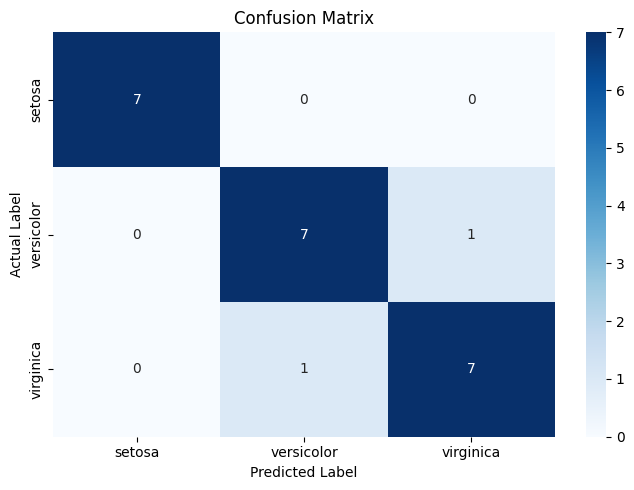

In [ ]:
# ============================================================
# BASIC SUPERVISED LEARNING PIPELINE
# ============================================================

# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", iris.target_names)


# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split")
print("----------------")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 3. CREATE CLASSIFIER
# ============================================================

classifier = DecisionTreeClassifier(
    random_state=42
)


# ============================================================
# 4. TRAIN THE CLASSIFIER
# ============================================================

classifier.fit(
    X_train,
    y_train
)

print("\nModel training completed.")


# ============================================================
# 5. MAKE PREDICTIONS
# ============================================================

y_pred = classifier.predict(
    X_test
)

print("Predictions completed.")


# ============================================================
# 6. CALCULATE EVALUATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names,
        zero_division=0
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix")
print("----------------")

print(cm)


# ============================================================
# 10. VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()